In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

In [18]:
matches_df=pd.read_csv('/content/matches (1).csv')
matches_df
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             74 non-null     int64  
 1   date                 74 non-null     object 
 2   venue                74 non-null     object 
 3   team1                74 non-null     object 
 4   team2                74 non-null     object 
 5   stage                74 non-null     object 
 6   toss_winner          74 non-null     object 
 7   toss_decision        74 non-null     object 
 8   first_ings_score     73 non-null     float64
 9   first_ings_wkts      73 non-null     float64
 10  second_ings_score    73 non-null     float64
 11  second_ings_wkts     73 non-null     float64
 12  match_result         74 non-null     object 
 13  match_winner         73 non-null     object 
 14  wb_runs              26 non-null     float64
 15  wb_wickets           46 non-null     float

In [19]:
matches_df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
69,70,"May 19, 2026","Eden Gardens, Kolkata",KKR,RR,League,RR,Bowl,155.0,8.0,...,KKR,NaN,4.0,8.0,Rinku Singh,Rinku Singh,64.0,Varun Chakravarthy,3--21,No
70,71,"May 26, 2026","HPCA Cricket Stadium, Dharamshala",RCB,GT,Qualifier 1,GT,Bowl,254.0,5.0,...,RCB,92.0,NaN,3.0,Rajat Patidar,Rajat Patidar,93.0,Jacob Duffy,3--39,No
71,72,"May 27, 2026",Maharaja Yadavindra Singh International Cricke...,RR,SRH,Eliminator,SRH,Bowl,243.0,8.0,...,RR,47.0,NaN,5.0,Vaibhav Sooryavanshi,Vaibhav Sooryavanshi,97.0,Jofra Archer,3--32,No
72,73,"May 29, 2026",Maharaja Yadavindra Singh International Cricke...,RR,GT,Qualifier 2,RR,Bat,214.0,6.0,...,GT,NaN,7.0,8.0,Shubman Gill,Shubman Gill,104.0,Jofra Archer,1--45,No
73,74,"May 31, 2026","Narendra Modi Stadium, Ahmedabad",RCB,GT,Final,RCB,Bowl,155.0,8.0,...,RCB,NaN,5.0,12.0,Virat Kohli,Virat Kohli,75.0,Rasikh Salam,3--27,No


In [20]:
deliveries_df=pd.read_csv('/content/deliveries.csv')
deliveries_df
deliveries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15778 entries, 0 to 15777
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_no          15778 non-null  int64  
 1   date              15778 non-null  object 
 2   stage             15778 non-null  object 
 3   venue             15778 non-null  object 
 4   batting_team      15778 non-null  object 
 5   bowling_team      15778 non-null  object 
 6   innings           15778 non-null  int64  
 7   over              15778 non-null  float64
 8   striker           15778 non-null  object 
 9   bowler            15778 non-null  object 
 10  runs_of_bat       15777 non-null  float64
 11  extras            15777 non-null  float64
 12  wide              15777 non-null  float64
 13  legbyes           15777 non-null  float64
 14  byes              15777 non-null  float64
 15  noballs           15777 non-null  float64
 16  wicket_type       782 non-null    object

TO DROP THE ROW WHERE MATCH HAS BEEN DISCARDE

In [21]:
matches_clean = matches_df.dropna(subset=['match_winner'])

In [22]:
venue_clean_map = {
    "M. Chinnaswamy Stadium, Bangalore": "M. Chinnaswamy Stadium, Bengaluru",
    "M.Chinnaswamy Stadium, Bengaluru": "M. Chinnaswamy Stadium, Bengaluru",
    "M. A. Chidambaram Stadium, Chennai": "MA Chidambaram Stadium, Chennai",
    "M.Chidambaram Stadium, Chennai": "MA Chidambaram Stadium, Chennai"
}
matches_clean['venue'] = matches_clean['venue'].replace(venue_clean_map)
deliveries_df['venue'] = deliveries_df['venue'].replace(venue_clean_map)

/tmp/ipykernel_1809/2397426032.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean['venue'] = matches_clean['venue'].replace(venue_clean_map)


In [23]:
for col in ['team1', 'team2', 'toss_winner', 'match_winner', 'toss_decision', 'stage']:
    matches_clean[col] = matches_clean[col].astype(str).str.strip()

for col in ['batting_team', 'bowling_team', 'striker', 'bowler', 'stage']:
    deliveries_df[col] = deliveries_df[col].astype(str).str.strip()

/tmp/ipykernel_1809/19514720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean[col] = matches_clean[col].astype(str).str.strip()
/tmp/ipykernel_1809/19514720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean[col] = matches_clean[col].astype(str).str.strip()
/tmp/ipykernel_1809/19514720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

TO SHOW THE ***WINNING STRATEGY***, LIKE WHO WINS ***BATTING*** FIRST OR ***BOWLING***

/tmp/ipykernel_1809/4003617728.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_clean['winning_strategy'] = matches_clean.apply(get_winning_strategy, axis=1)


Saved: 'win_strategy_distribution.png'


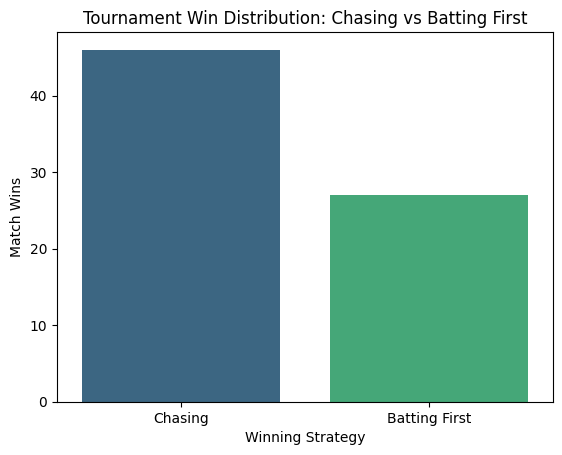

In [24]:
def get_winning_strategy(row):
    if row['toss_winner'] == row['match_winner']:
        return 'Chasing' if row['toss_decision'] == 'Bowl' else 'Batting First'
    else:
        return 'Batting First' if row['toss_decision'] == 'Bowl' else 'Chasing'

matches_clean['winning_strategy'] = matches_clean.apply(get_winning_strategy, axis=1)

plt.figure()
sns.countplot(data=matches_clean, x='winning_strategy', palette='viridis', hue='winning_strategy', legend=False)
plt.title('Tournament Win Distribution: Chasing vs Batting First')
plt.xlabel('Winning Strategy')
plt.ylabel('Match Wins')
plt.savefig('win_strategy_distribution.png')
print("Saved: 'win_strategy_distribution.png'")

TO ANALYSE THE FIRST INNINGS SCORE OF 2026 IPL ***VENUES***

Saved: 'venue_pitch_behavior.png'



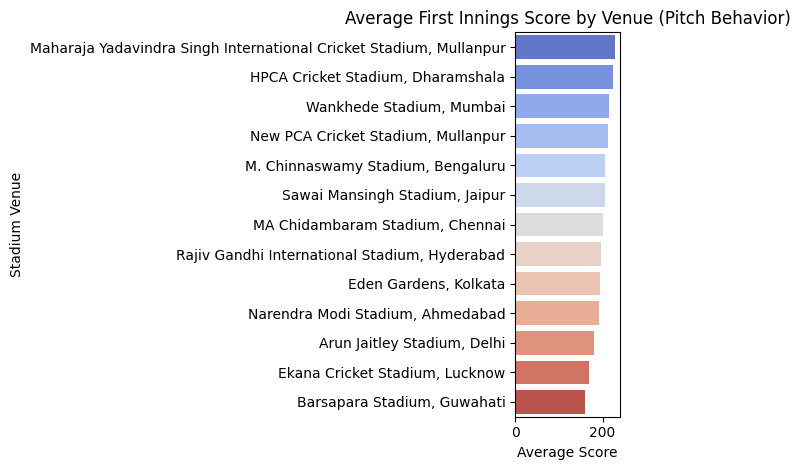

In [25]:
venue_scores = matches_clean.groupby('venue')['first_ings_score'].mean().reset_index()
venue_scores = venue_scores.sort_values(by='first_ings_score', ascending=False)

plt.figure()
sns.barplot(data=venue_scores, y='venue', x='first_ings_score', palette='coolwarm', hue='venue', legend=False)
plt.title('Average First Innings Score by Venue (Pitch Behavior)')
plt.xlabel('Average Score')
plt.ylabel('Stadium Venue')
plt.tight_layout()
plt.savefig('venue_pitch_behavior.png')
print("Saved: 'venue_pitch_behavior.png'\n")

PHASE WISE RUNS ANALYSIS

In [26]:
def assign_phase(over):
    if over < 6.0: return 'Powerplay (0-6)'
    elif over < 15.0: return 'Middle Overs (6-15)'
    else: return 'Death Overs (15-20)'

deliveries_df['match_phase'] = deliveries_df['over'].apply(assign_phase)

Calculate Strike Rates of Top Players across Match Phases

In [27]:
batsmen_phase = deliveries_df.groupby(['striker', 'match_phase']).agg(
    total_runs=('runs_of_bat', 'sum'),
    balls_faced=('wide', lambda x: (x == 0).sum()) # Only legal deliveries counted
).reset_index()

batsmen_phase['strike_rate'] = (batsmen_phase['total_runs'] / batsmen_phase['balls_faced']) * 100

BREAKING VIRAT KOHLI'S PHASE WISE RUNS , BALLS FACED AND STRIKE RATE

In [28]:
kohli_profile = batsmen_phase[batsmen_phase['striker'] == 'Virat Kohli']
print("Virat Kohli Phase Breakdown Metrics:")
print(kohli_profile.to_string(index=False), "\n")

Virat Kohli Phase Breakdown Metrics:
    striker         match_phase  total_runs  balls_faced  strike_rate
Virat Kohli Death Overs (15-20)        49.0           18   272.222222
Virat Kohli Middle Overs (6-15)       217.0          147   147.619048
Virat Kohli     Powerplay (0-6)       291.0          176   165.340909 



VAIBHAV SOORYAVANSHI'S PHASE WISE RUNS , BALLS FACED AND STRIKE RATE

In [29]:
vaibhav_profile = batsmen_phase[batsmen_phase['striker'] == 'Vaibhav Sooryavanshi']
print("Vaibhav Sooryavanshi Phase Breakdown Metrics:")
print(vaibhav_profile.to_string(index=False), "\n")

Vaibhav Sooryavanshi Phase Breakdown Metrics:
             striker         match_phase  total_runs  balls_faced  strike_rate
Vaibhav Sooryavanshi Middle Overs (6-15)       153.0           65   235.384615
Vaibhav Sooryavanshi     Powerplay (0-6)       426.0          180   236.666667 



RAJAT PATIDAR'S PHASE WISE RUNS , BALLS FACED AND STRIKE RATE

In [30]:
rajat_profile = batsmen_phase[batsmen_phase['striker'] == 'Rajat Patidar']
print("Rajat patidar Phase Breakdown Metrics:")
print(rajat_profile.to_string(index=False), "\n")

Rajat patidar Phase Breakdown Metrics:
      striker         match_phase  total_runs  balls_faced  strike_rate
Rajat Patidar Death Overs (15-20)        85.0           41   207.317073
Rajat Patidar Middle Overs (6-15)       271.0          133   203.759398
Rajat Patidar     Powerplay (0-6)        36.0           39    92.307692 



SHUBMAN GILL'S PHASE WISE RUNS , BALLS FACED AND STRIKE RATE

In [31]:
gill_profile = batsmen_phase[batsmen_phase['striker'] == 'Shubman Gill']
print("Shubman Gill Phase Breakdown Metrics:")
print(gill_profile.to_string(index=False), "\n")

Shubman Gill Phase Breakdown Metrics:
     striker         match_phase  total_runs  balls_faced  strike_rate
Shubman Gill Death Overs (15-20)        37.0           25   148.000000
Shubman Gill Middle Overs (6-15)       290.0          181   160.220994
Shubman Gill     Powerplay (0-6)       289.0          175   165.142857 



Dot Balls & Valid Bowler Wickets

In [32]:
deliveries_df['is_dot_ball'] = ((deliveries_df['runs_of_bat'] == 0) &
                                (deliveries_df['wide'] == 0) &
                                (deliveries_df['noballs'] == 0)).astype(int)

deliveries_df['is_bowler_wicket'] = (~deliveries_df['wicket_type'].isna() &
                                     ~deliveries_df['wicket_type'].isin(['No Wicket', 'runout', 'retired hurt', 'retired out'])).astype(int)

deliveries_df['runs_conceded'] = deliveries_df['runs_of_bat'] + deliveries_df['wide'] + deliveries_df['noballs']

In [33]:
bowler_mvp = deliveries_df.groupby('bowler').agg(
    wickets=('is_bowler_wicket', 'sum'),
    runs_given=('runs_conceded', 'sum'),
    dots=('is_dot_ball', 'sum')
).reset_index()

In [34]:
bowler_mvp['bowling_impact_score'] = (bowler_mvp['wickets'] * 25) + (bowler_mvp['dots'] * 1) - (bowler_mvp['runs_given'] * 0.5)
top_5_mvp = bowler_mvp.sort_values(by='bowling_impact_score', ascending=False).head(5)

print("Top 5 Impact Bowlers of the Tournament (Custom MVP Index):")
print(top_5_mvp.to_string(index=False), "\n")

Top 5 Impact Bowlers of the Tournament (Custom MVP Index):
           bowler  wickets  runs_given  dots  bowling_impact_score
Bhuvneshwar Kumar       24       443.0   127                 505.5
    Kagiso Rabada       24       492.0   147                 501.0
     Sunil Narine       16       302.0   131                 380.0
    Anshul Kamboj       21       527.0   116                 377.5
      Rashid Khan       19       409.0   103                 373.5 



BOWLERS' PHASE BY PHASE STATS

In [35]:
deliveries_df['is_legal_ball'] = ((deliveries_df['wide'] == 0) & (deliveries_df['noballs'] == 0)).astype(int)

phase_bowlers = deliveries_df.groupby(['bowler', 'match_phase']).agg(
    wickets=('is_bowler_wicket', 'sum'),
    runs=('runs_conceded', 'sum'),
    balls=('is_legal_ball', 'sum')
).reset_index()

phases = deliveries_df['match_phase'].unique()

for phase in phases:
    print(f"\n--- {phase} ---")

    # Filter for the current phase
    phase_df = phase_bowlers[phase_bowlers['match_phase'] == phase].copy()

    # Compute standard cricket metrics
    phase_df['overs'] = (phase_df['balls'] / 6).round(1)
    phase_df['economy'] = (phase_df['runs'] / (phase_df['balls'] / 6)).round(2)

    # Sort by wickets (primary - descending) and economy (secondary - ascending)
    top_5 = phase_df.sort_values(by=['wickets', 'economy'], ascending=[False, True]).head(5)

    # Clean up display formatting
    print(top_5[['bowler', 'wickets', 'overs', 'runs', 'economy']].to_string(index=False))


--- Powerplay (0-6) ---
           bowler  wickets  overs  runs  economy
    Kagiso Rabada       17   37.0 341.0     9.22
Bhuvneshwar Kumar       15   30.0 212.0     7.07
   Mohammed Siraj       13   39.0 293.0     7.51
     Jofra Archer        9   26.0 242.0     9.31
   Mohammed Shami        7   28.0 210.0     7.50

--- Middle Overs (6-15) ---
         bowler  wickets  overs  runs  economy
    Rashid Khan       17   39.8 344.0     8.64
     Noor Ahmad       12   46.0 373.0     8.11
Prasidh Krishna       12   22.0 209.0     9.50
  Krunal Pandya       11   39.2 334.0     8.53
  Jamie Overton        9   16.0 121.0     7.56

--- Death Overs (15-20) ---
           bowler  wickets  overs  runs  economy
    Anshul Kamboj       13   21.3 235.0    11.02
     Sunil Narine        9    9.0  49.0     5.44
     Kartik Tyagi        9   18.0 190.0    10.56
Bhuvneshwar Kumar        8   20.0 182.0     9.10
 Rasikh Salam Dar        8   10.8 108.0     9.97


FILTERING TOP 10 BATSMAN AND TOP 10 BOWLERS

In [37]:
top_batsmen = deliveries_df.groupby('striker')['runs_of_bat'].sum().sort_values(ascending=False).head(10).index
top_bowlers = deliveries_df.groupby('bowler').size().sort_values(ascending=False).head(10).index
h2h_df = deliveries_df[deliveries_df['striker'].isin(top_batsmen) & deliveries_df['bowler'].isin(top_bowlers)]

Saved: 'batsman_bowler_matchups.png'


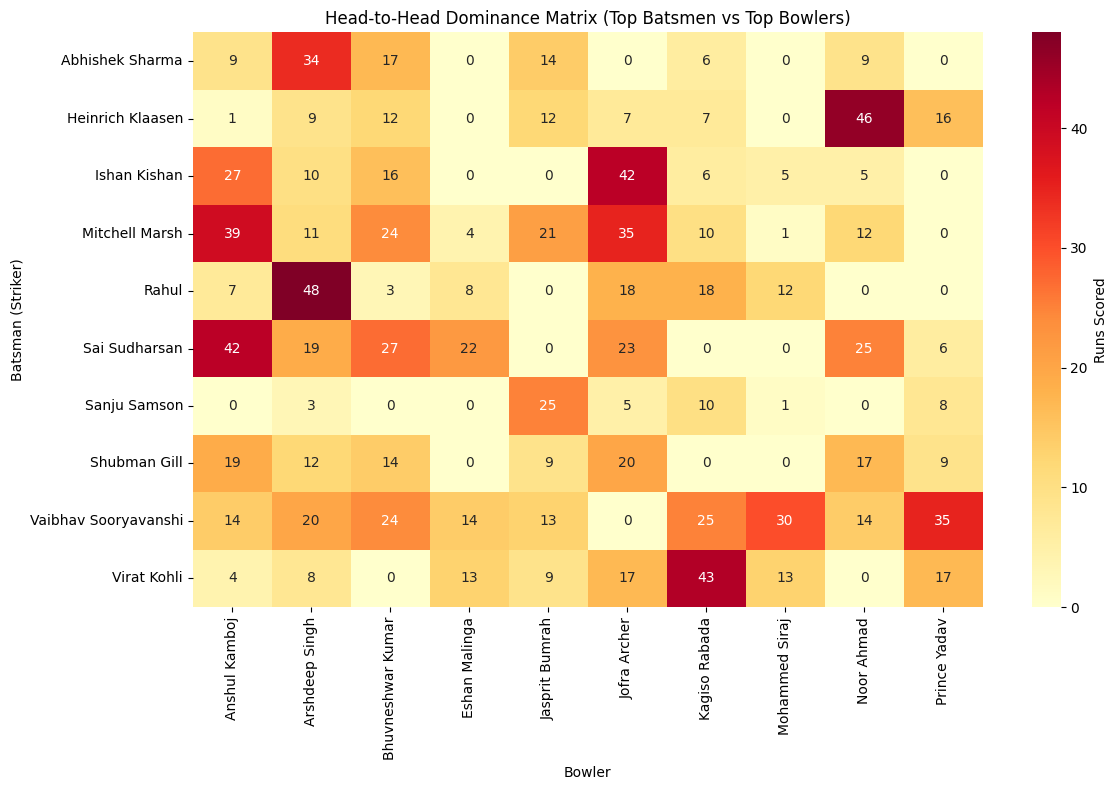

In [38]:
matchup_matrix = h2h_df.pivot_table(values='runs_of_bat', index='striker', columns='bowler', aggfunc='sum').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(matchup_matrix, annot=True, cmap='YlOrRd', fmt='g', cbar_kws={'label': 'Runs Scored'})
plt.title('Head-to-Head Dominance Matrix (Top Batsmen vs Top Bowlers)')
plt.ylabel('Batsman (Striker)')
plt.xlabel('Bowler')
plt.tight_layout()
plt.savefig('batsman_bowler_matchups.png')
print("Saved: 'batsman_bowler_matchups.png'")

RUNS PER OVER OF TEAMS

In [39]:
deliveries_df['over_integer'] = deliveries_df['over'].astype(int)

team_momentum = deliveries_df.groupby(['batting_team', 'over_integer'])['runs_of_bat'].sum().reset_index()
team_momentum['cumulative_runs'] = team_momentum.groupby('batting_team')['runs_of_bat'].cumsum()

Saved: 'team_scoring_momentum.png'


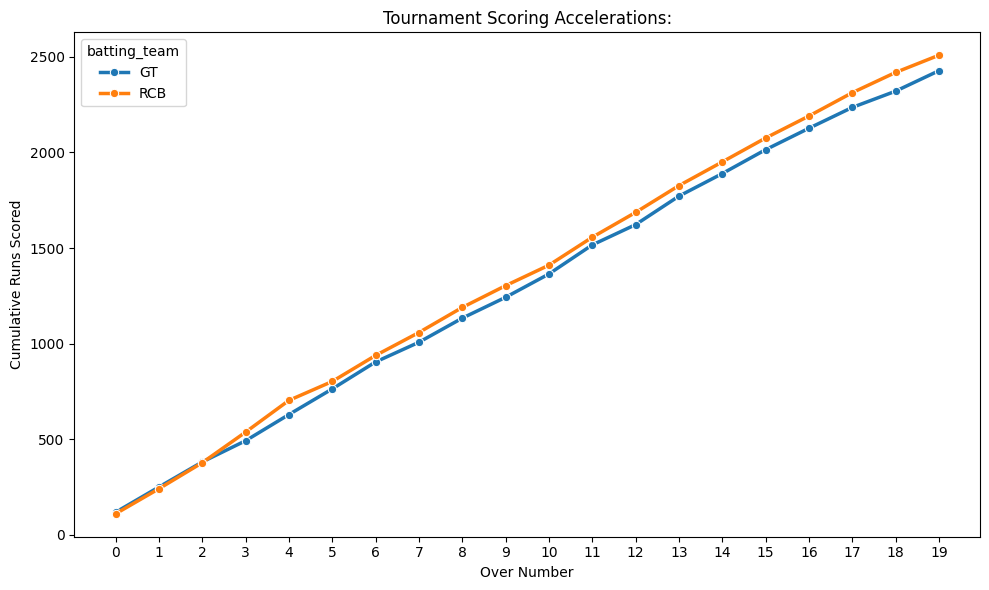

In [45]:
finalists = team_momentum[team_momentum['batting_team'].isin(['RCB', 'GT'])]
plt.figure(figsize=(10, 6))
sns.lineplot(data=finalists, x='over_integer', y='cumulative_runs', hue='batting_team', marker='o', linewidth=2.5)
plt.title('Tournament Scoring Accelerations:')
plt.xlabel('Over Number')
plt.ylabel('Cumulative Runs Scored')
plt.xticks(range(0, 20))
plt.tight_layout()
plt.savefig('team_scoring_momentum.png')
print("Saved: 'team_scoring_momentum.png'")

1. ***The Strategic Supremacy of ChasingThe "Bowl First" Formula:***

The tournament heavily favored teams that won the toss and elected to field first. Chasing teams won $63.01\%$ ($46$ out of $73$) of all completed matches.Toss Decision Disparity: Captains who chose to bowl first enjoyed a highly successful $58.33\%$ win rate.

Conversely, electing to bat first proved to be a highly flawed strategy, resulting in a meager $14.29\%$ win rate for the toss-winner. This emphasizes that pitch normalization under lights or dew factors made chasing a clear tactical advantage.

2. **Team Dominance & Campaign Execution**

RCB's Golden Season:
:Royal Challengers Bengaluru (RCB) was undisputedly the most dominant team of the 2026 season, securing a tournament-high $14$ wins and capping it off by defeating Gujarat Titans (GT) in the Final.

Aggressive Frameworks: The two finalists, RCB and GT, showed contrasting strengths. GT excelled at control and finding gaps (leading the tournament with $292$ fours), whereas teams like Rajasthan Royals (RR) relied on sheer clearing power (leading with $181$ sixes).

3. *Individual High-Impact PerformersGenerational Batting Efficiency:*

Vaibhav Sooryavanshi emerged as the most explosive asset of the tournament, scoring 776 runs at an unbelievable strike rate of 237.31. Meanwhile, Virat Kohli provided masterclass stabilization, anchoring his team to the title with a tournament-high average of 56.25.

Multi-Phase Bowling Masters: While Kagiso Rabada dominated the Powerplay (20 wickets) and Rashid Khan locked down the Middle Overs (19 wickets), Bhuvneshwar Kumar was the ultimate defensive and offensive weapon. He tied as the joint-highest wicket-taker (29 wickets) while maintaining an elite economy rate of 7.94 across both the Powerplay and Death Overs.